# Import libraries

In [6]:
from pgmpy.models import DynamicBayesianNetwork as DBN
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import DBNInference

In [73]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.dynamicBN as gdyn

# pgmpy

## Examples

In [9]:
# A helper function to compute probability distributions from simulated samples.
def get_distribution(samples, variables=None):
    """
    For marginal distribution, P(A): get_distribution(samples, variables=['A'])
    For joint distribution, P(A, B): get_distribution(samples, variables=['A', 'B'])
    """
    if variables is None:
        raise ValueError("variables must be specified")

    return samples.groupby(variables, observed=False).size() / samples.shape[0]

In [20]:
# Do not print warnings
import logging
from pgmpy.global_vars import logger
logger.setLevel(logging.ERROR)

# Specify the model to simulate data from.
from pgmpy.factors.discrete import TabularCPD
from pgmpy.utils import get_example_model

import numpy as np
import pandas as pd
# Set the option to display all columns
pd.options.display.max_columns = None

alarm = get_example_model("alarm")

In [21]:
samples = alarm.simulate(n_samples=int(1e4))
samples.head()

Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 155.60it/s]      


,SAO2,VENTALV,HYPOVOLEMIA,INTUBATION,VENTTUBE,MINVOL,HRSAT,DISCONNECT,CO,TPR,KINKEDTUBE,CVP,BP,PVSAT,PRESS,FIO2,ERRCAUTER,SHUNT,HR,VENTMACH,PAP,ANAPHYLAXIS,MINVOLSET,VENTLUNG,STROKEVOLUME,HISTORY,INSUFFANESTH,LVEDVOLUME,EXPCO2,PULMEMBOLUS,ARTCO2,CATECHOL,HRBP,PCWP,LVFAILURE,HREKG,ERRLOWOUTPUT
0,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,HIGH,TRUE,NORMAL,HIGH,LOW,LOW,NORMAL,FALSE,NORMAL,HIGH,NORMAL,NORMAL,FALSE,NORMAL,ZERO,NORMAL,FALSE,FALSE,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
1,LOW,ZERO,FALSE,NORMAL,ZERO,ZERO,NORMAL,FALSE,LOW,NORMAL,FALSE,LOW,LOW,LOW,HIGH,NORMAL,TRUE,NORMAL,HIGH,ZERO,NORMAL,FALSE,NORMAL,ZERO,LOW,TRUE,FALSE,LOW,LOW,FALSE,HIGH,HIGH,HIGH,LOW,TRUE,NORMAL,FALSE
2,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,LOW,FALSE,NORMAL,LOW,LOW,HIGH,NORMAL,FALSE,NORMAL,HIGH,NORMAL,NORMAL,FALSE,NORMAL,ZERO,NORMAL,FALSE,FALSE,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
3,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,NORMAL,FALSE,HIGH,LOW,FALSE,NORMAL,LOW,LOW,NORMAL,NORMAL,TRUE,NORMAL,HIGH,NORMAL,NORMAL,FALSE,NORMAL,ZERO,NORMAL,FALSE,FALSE,NORMAL,LOW,FALSE,HIGH,HIGH,NORMAL,NORMAL,FALSE,NORMAL,FALSE
4,HIGH,HIGH,FALSE,NORMAL,LOW,HIGH,HIGH,FALSE,HIGH,NORMAL,FALSE,NORMAL,NORMAL,HIGH,HIGH,NORMAL,FALSE,NORMAL,HIGH,NORMAL,NORMAL,FALSE,NORMAL,LOW,NORMAL,FALSE,FALSE,NORMAL,LOW,FALSE,LOW,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE


In [12]:
evidence = {"CVP": "NORMAL", "HR": "HIGH"}
samples = alarm.simulate(n_samples=int(1e4), evidence=evidence)
samples.head()

100%|██████████| 10000/10000 [00:00<00:00, 23459.05it/s]


,SAO2,VENTALV,HYPOVOLEMIA,INTUBATION,VENTTUBE,MINVOL,HRSAT,DISCONNECT,CO,TPR,...,LVEDVOLUME,EXPCO2,PULMEMBOLUS,ARTCO2,CATECHOL,HRBP,PCWP,LVFAILURE,HREKG,ERRLOWOUTPUT
0,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,NORMAL,...,NORMAL,ZERO,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
1,LOW,HIGH,FALSE,NORMAL,HIGH,HIGH,HIGH,FALSE,HIGH,NORMAL,...,NORMAL,ZERO,FALSE,NORMAL,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
2,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,NORMAL,...,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
3,LOW,ZERO,TRUE,NORMAL,LOW,ZERO,NORMAL,FALSE,HIGH,NORMAL,...,HIGH,LOW,FALSE,HIGH,HIGH,HIGH,HIGH,FALSE,NORMAL,FALSE
4,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,LOW,...,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE


In [13]:
# All values of HR and CVP should be set to HIGH and NORMAL respectively.
print(all(samples.HR == "HIGH"))
print(all(samples.CVP == "NORMAL"))

True
True


In [14]:
# The virtual evidence is specified using TabularCPDs. Here, P(CVP=NORMAL) = 0.2, P(CVP=LOW) = 0.3, and P(CPV=HIGH) = 0.5
cvp_evidence = TabularCPD(variable="CVP",
                          variable_card=3,
                          values=[[0.2], [0.3], [0.5]],
                          state_names={"CVP": ["LOW", "NORMAL", "HIGH"]})
samples = alarm.simulate(n_samples=int(1e4), virtual_evidence=[cvp_evidence])

100%|██████████| 10000/10000 [00:01<00:00, 8587.70it/s]


In [15]:
# Check the marginal distribution of CVP
get_distribution(samples, variables=['CVP'])

CVP
HIGH      0.2416
LOW       0.0707
NORMAL    0.6877
dtype: float64

In [16]:
samples = alarm.simulate(n_samples=int(1e4), do={"CVP": "NORMAL", "HR": "HIGH"})
samples.head()

100%|██████████| 10000/10000 [00:01<00:00, 7169.24it/s]


,SAO2,VENTALV,HYPOVOLEMIA,INTUBATION,VENTTUBE,MINVOL,HRSAT,DISCONNECT,CO,TPR,...,LVEDVOLUME,EXPCO2,PULMEMBOLUS,ARTCO2,CATECHOL,HRBP,PCWP,LVFAILURE,HREKG,ERRLOWOUTPUT
0,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,NORMAL,...,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
1,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,LOW,...,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
2,HIGH,HIGH,FALSE,NORMAL,ZERO,HIGH,HIGH,FALSE,HIGH,NORMAL,...,NORMAL,LOW,FALSE,LOW,HIGH,HIGH,NORMAL,FALSE,HIGH,FALSE
3,LOW,ZERO,FALSE,NORMAL,LOW,HIGH,NORMAL,FALSE,HIGH,NORMAL,...,NORMAL,NORMAL,FALSE,HIGH,HIGH,NORMAL,NORMAL,FALSE,NORMAL,FALSE
4,LOW,ZERO,FALSE,NORMAL,LOW,ZERO,HIGH,FALSE,HIGH,HIGH,...,NORMAL,LOW,FALSE,HIGH,HIGH,HIGH,LOW,FALSE,HIGH,FALSE


In [ ]:
cvp_intervention = TabularCPD(variable="CVP",
                              variable_card=3,
                              values=[[0.2], [0.3], [0.5]],
                              state_names={"CVP": ["LOW", "NORMAL", "HIGH"]})
samples = alarm.simulate(n_samples=int(1e4), virtual_intervention=[cvp_intervention])
get_distribution(samples, variables=["CVP"])  # P(HISTORY)

100%|██████████| 10000/10000 [00:00<00:00, 11382.02it/s]


CVP
HIGH      0.3802
LOW       0.2121
NORMAL    0.4077
dtype: float64

In [ ]:
# Generate some data on CVP.
partial_cvp = pd.DataFrame(np.random.choice(["LOW", "NORMAL", "HIGH"], int(1e4)), columns=['CVP'])
samples = alarm.simulate(n_samples=int(1e4), partial_samples=partial_cvp)

Generating for node: BP: 100%|██████████| 37/37 [00:00<00:00, 150.31it/s]      


In [ ]:
print(all(samples["CVP"] == partial_cvp["CVP"]))

True


## DBN

In [22]:
dbn = DBN()

In [55]:
# a two-timeslice Bayesian network (2-TBN)
# For DBNs, the variable must be time-indexed
dbn.add_edges_from(
    [
        (("D", 0), ("G", 0)),
        (("I", 0), ("G", 0)),
        (("G", 0), ("L", 0)),
        (("D", 0), ("D", 1)),
        (("I", 0), ("I", 1)),
        (("G", 0), ("G", 1)),
        (("G", 0), ("L", 1)),
        (("L", 0), ("L", 1)),
    ]
)

In [34]:
# query the edges and nodes in the network
dbn.nodes()

NodeView((<DynamicNode(D, 0) at 0x1974de5f210>, <DynamicNode(G, 0) at 0x1974de5f450>, <DynamicNode(D, 1) at 0x1974de5d810>, <DynamicNode(G, 1) at 0x1974de5f8d0>, <DynamicNode(I, 0) at 0x1974de5fdd0>, <DynamicNode(I, 1) at 0x1974de5fb50>, <DynamicNode(L, 0) at 0x1974de42090>, <DynamicNode(L, 1) at 0x1974cfdbcd0>, <DynamicNode(S, 0) at 0x19750e2e9d0>))

In [35]:
dbn.edges()

OutEdgeView([(<DynamicNode(D, 0) at 0x1974de5f210>, <DynamicNode(G, 0) at 0x1974de5f450>), (<DynamicNode(D, 0) at 0x1974de5f210>, <DynamicNode(D, 1) at 0x1974ec2c6d0>), (<DynamicNode(G, 0) at 0x1974de5f450>, <DynamicNode(L, 0) at 0x1974de42090>), (<DynamicNode(G, 0) at 0x1974de5f450>, <DynamicNode(G, 1) at 0x1974ec20d90>), (<DynamicNode(G, 0) at 0x1974de5f450>, <DynamicNode(L, 1) at 0x19751e0eb90>), (<DynamicNode(D, 1) at 0x1974de5d810>, <DynamicNode(G, 1) at 0x1974de5f8d0>), (<DynamicNode(G, 1) at 0x1974de5f8d0>, <DynamicNode(L, 1) at 0x1974cfdbcd0>), (<DynamicNode(I, 0) at 0x1974de5fdd0>, <DynamicNode(G, 0) at 0x1974de5e090>), (<DynamicNode(I, 0) at 0x1974de5fdd0>, <DynamicNode(I, 1) at 0x1974ec224d0>), (<DynamicNode(I, 1) at 0x1974de5fb50>, <DynamicNode(G, 1) at 0x1974de40310>), (<DynamicNode(L, 0) at 0x1974de42090>, <DynamicNode(L, 1) at 0x1974ec46250>)])

In [36]:
dbn.add_node("S")
dbn.nodes()

NodeView((<DynamicNode(D, 0) at 0x1974de5f210>, <DynamicNode(G, 0) at 0x1974de5f450>, <DynamicNode(D, 1) at 0x1974de5d810>, <DynamicNode(G, 1) at 0x1974de5f8d0>, <DynamicNode(I, 0) at 0x1974de5fdd0>, <DynamicNode(I, 1) at 0x1974de5fb50>, <DynamicNode(L, 0) at 0x1974de42090>, <DynamicNode(L, 1) at 0x1974cfdbcd0>, <DynamicNode(S, 0) at 0x19750e2e9d0>))

In [ ]:
type(next(iter(dbn.nodes())))
# -> pgmpy.models.DynamicBayesianNetwork.DynamicNode

pgmpy.models.DynamicBayesianNetwork.DynamicNode

In [42]:
dbn.get_slice_nodes(0)  # nodes at time 0
dbn.get_slice_nodes(1)  # nodes at time 1

[<DynamicNode(I, 1) at 0x1974e5d3bd0>,
 <DynamicNode(L, 1) at 0x19750f60f50>,
 <DynamicNode(S, 1) at 0x19750f60810>,
 <DynamicNode(G, 1) at 0x19750f60550>,
 <DynamicNode(D, 1) at 0x19750f625d0>]

In [40]:
n = next(iter(dbn.nodes()))
dir(n)

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'node',
 'time_slice',
 'to_tuple']

In [44]:
sorted({n.node for n in dbn.nodes()})

['D', 'G', 'I', 'L', 'S']

In [45]:
sorted([(n.node, n.time_slice) for n in dbn.nodes()])

[('D', 0),
 ('D', 1),
 ('G', 0),
 ('G', 1),
 ('I', 0),
 ('I', 1),
 ('L', 0),
 ('L', 1),
 ('S', 0)]

In [ ]:
edges = [((u.node, u.time_slice), (v.node, v.time_slice))
         for u, v in dbn.edges()]
edges

[(('D', 0), ('G', 0)),
 (('D', 0), ('D', 1)),
 (('G', 0), ('L', 0)),
 (('G', 0), ('G', 1)),
 (('G', 0), ('L', 1)),
 (('D', 1), ('G', 1)),
 (('G', 1), ('L', 1)),
 (('I', 0), ('G', 0)),
 (('I', 0), ('I', 1)),
 (('I', 1), ('G', 1)),
 (('L', 0), ('L', 1))]

In [48]:
from pgmpy.base import DAG
student = DAG()
student.add_nodes_from(["diff", "intel", "grades"])
student.add_edges_from([("diff", "grades"), ("intel", "grades")])
student.active_trail_nodes("diff")
student.active_trail_nodes(["diff", "intel"], observed="grades")

{'diff': {'diff', 'intel'}, 'intel': {'diff', 'intel'}}

### Conditional probability distribution (CPD)
- add_cpds(*cpds): This method adds the cpds to the Dynamic Bayesian Network. Note that while adding variables and the evidence in cpd, they have to be of the following form (node_name, time_slice) Here, node_name is the node that is inserted while the time_slice is an integer value, which denotes the index of the time_slice that the node belongs to.

In [ ]:
from pgmpy.models import DynamicBayesianNetwork as DBN
from pgmpy.factors.discrete import TabularCPD
dbn = DBN()
# time slices:
# t0: I(0), D(0), G(0)
# t1: I(1), D(1)
dbn.add_edges_from(
    [
        (("D", 0), ("G", 0)),
        (("I", 0), ("G", 0)),
        (("D", 0), ("D", 1)),
        (("I", 0), ("I", 1)),
    ]
)

In [58]:
dbn.check_model()

True

- A `TabularCPD` defines: $$P(X|Parents(X))$$
- The `grade_cpd` defines: $$P(G_0|I_0,D_0)$$
- The `diff_cpd` defines: (This is a prior, no parents.) $$P(D_0)$$
- The `intel_cpd` defines: $$P(I_0)$$
- The `d_i_cpd` defines Difficulty transition CPD: $$P(D_1|D_0)$$
- The `i_i_cpd` defines Intelligence transition CPD: $$P(I_1|I_0)$$

In [ ]:
grade_cpd = TabularCPD(
    ("G", 0), # this CPD defines Grade at time 0
    3, # three possible grade outcomes (A, B, C)
    [[0.3, 0.05, 0.9, 0.5], [0.4, 0.25, 0.08, 0.3], [0.3, 0.7, 0.02, 0.2]], # Column 0: low intelligence, easy course [0.3, 0.4, 0.3]; Column 1: low intelligence, hard course [0.05, 0.25, 0.7]
    evidence=[("I", 0), ("D", 0)], # Each has 2 states, so the CPD must have 4 columns
    evidence_card=[2, 2],
)

d_i_cpd = TabularCPD(
    ("D", 1),
    2,
    [[0.6, 0.3], [0.4, 0.7]],
    evidence=[("D", 0)],
    evidence_card=[2],
)
diff_cpd  = TabularCPD(("D", 0), 2, [[0.6], [0.4]])
intel_cpd = TabularCPD(("I", 0), 2, [[0.7], [0.3]])
i_i_cpd = TabularCPD(
    ("I", 1),
    2,
    [[0.5, 0.4], [0.5, 0.6]],
    evidence=[("I", 0)],
    evidence_card=[2],
)
dbn.add_cpds(grade_cpd, d_i_cpd, diff_cpd, intel_cpd, i_i_cpd)
dbn.get_cpds()

[<TabularCPD representing P(('D', 0):2) at 0x19751e2ce90>,
 <TabularCPD representing P(('I', 0):2) at 0x1975162eed0>,
 <TabularCPD representing P(('G', 0):3 | ('I', 0):2, ('D', 0):2) at 0x197516d8350>,
 <TabularCPD representing P(('D', 1):2 | ('D', 0):2) at 0x197516d8950>,
 <TabularCPD representing P(('I', 1):2 | ('I', 0):2) at 0x1975162f810>]

# pyAgrum (discrete-only)

In [63]:
bn = gum.BayesNet("WaterSprinkler")
print(bn)

BN{nodes: 0, arcs: 0, domainSize: 1, dim: 0, mem: 0o}


- pyAgrum(aGrUM) provides 5 types of variables:
    - LabelizedVariable {low|medium|high} : a discrete variable that can take 3 values.
    - RangeVariable [3,10] : a discrete variable that can take 8 values: from 3 to 10.
    - IntegerVariable {1|3|4|7} : a discrete variable that can take 4 values
    - NumericalDiscreteVariable {1.0|3.14|4.6|7} : another discrete variable that can take 4 values
    - DiscretizedVariable [1.0,3.0,6.0] :a continuous variable discretized in 2 values 1-3 and 3-6.

In [64]:
id_c = bn.add(gum.LabelizedVariable("c", "cloudy ?", 2))
print(id_c)

print(bn.variable(id_c))

0
c:Labelized({0|1})


In [65]:
id_s, id_r, id_w = [
  bn.add(name, 2) for name in "srw"
]  # bn.add(name, 2) === bn.add(gum.LabelizedVariable(name, name, 2))
print(id_s, id_r, id_w)
print(bn)

1 2 3
BN{nodes: 4, arcs: 0, domainSize: 16, dim: 4, mem: 64o}


In [66]:
print(f"{bn.variable(id_s)=}")
print(f"{bn['s']=}")
print(f"{id_s=}")
print(f"{bn.idFromName('s')=}")
print(f"{bn.variable(id_s).name()=}")

bn.variable(id_s)=(pyagrum.DiscreteVariable@0000019724809C70) s:Range([0,1])
bn['s']=(pyagrum.DiscreteVariable@0000019724809C70) s:Range([0,1])
id_s=1
bn.idFromName('s')=1
bn.variable(id_s).name()='s'


In [67]:
bn.addArc("c", "s")

In [68]:
for link in [(id_c, id_r), ("s", "w"), ("r", "w")]:
  bn.addArc(*link)
print(bn)

BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}


In [69]:
import pyagrum.lib.notebook as gnb

bn

(pyagrum.BayesNet@000001974AB86BB0) BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}

In [70]:
bn2 = gum.fastBN("c->r->w<-s<-c", "{No|Yes}")  # by default, variable is labelized {No|Yes}
bn2

(pyagrum.BayesNet@000001974AB96B70) BN{nodes: 4, arcs: 4, domainSize: 16, dim: 9, mem: 144o}

In [71]:
## hard coded BN
## twodbn=gum.BayesNet()
## a0,b0,c0,at,bt,ct=[twodbn.add(gum.LabelizedVariable(s,s,6))
#                   for s in ["a0","b0","c0","at","bt","ct"]]
## d0,dt=[twodbn.add(gum.LabelizedVariable(s,s,3))
#       for s in ["d0","dt"]]

## twodbn.addArc(a0,b0)

## twodbn.addArc(c0,d0)
## twodbn.addArc(c0,at)

## twodbn.addArc(a0,at)
## twodbn.addArc(a0,bt)
## twodbn.addArc(a0,dt)
## twodbn.addArc(b0,bt)
## twodbn.addArc(c0,ct)
## twodbn.addArc(d0,ct)
## twodbn.addArc(d0,dt)

## twodbn.addArc(at,ct)
## twodbn.generateCPTs()

## fast BN version

twodbn = gum.fastBN("d0[3]->ct<-at<-a0->b0->bt<-a0->dt[3]<-d0<-c0->ct;c0->at", 6)
twodbn

(pyagrum.BayesNet@000001974AB98E50) BN{nodes: 8, arcs: 11, domainSize: 419904, dim: 988, mem: 9Ko 384o}

## Dynamic Bayesian Networks

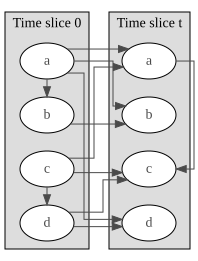

In [74]:
gdyn.showTimeSlices(twodbn)

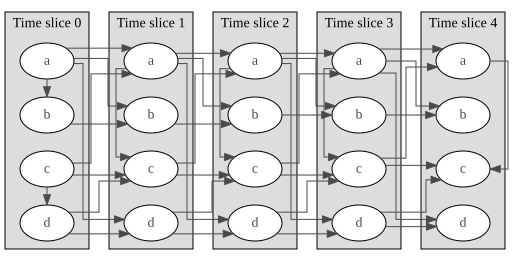

In [75]:
T = 5

dbn = gdyn.unroll2TBN(twodbn, T)
gdyn.showTimeSlices(dbn, size="10")


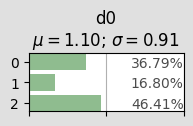
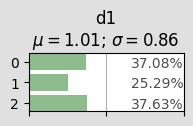
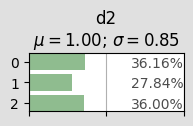
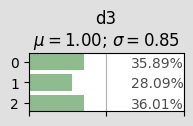
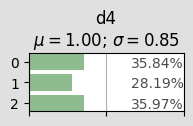

In [76]:
gnb.flow.clear()
for i in range(T):
  gnb.flow.add_html(gnb.getPosterior(dbn, target="d{}".format(i), evs={}), "$P(d{})$".format(i))
gnb.flow.display()

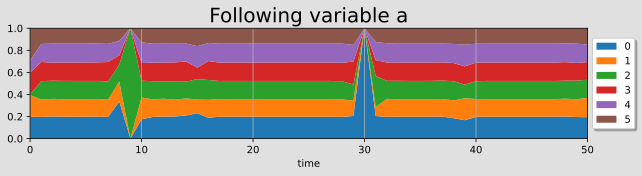

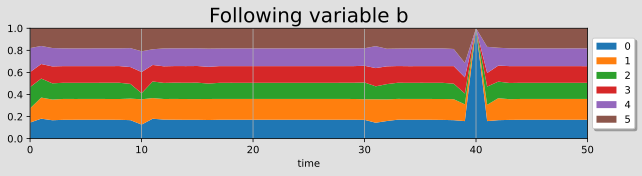

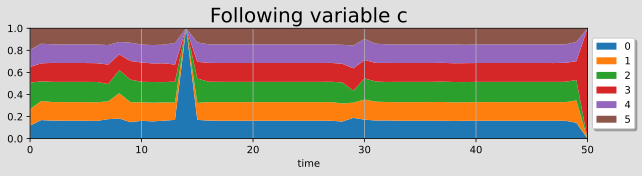

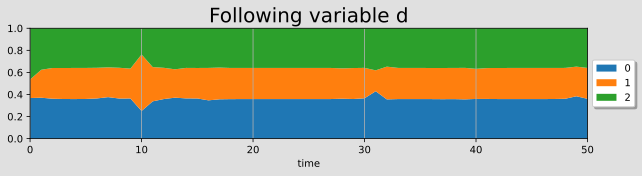

In [77]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 2)
gdyn.plotFollow(["a", "b", "c", "d"], twodbn, T=51, evs={"a9": 2, "a30": 0, "c14": 0, "b40": 0, "c50": 3})

### nsDBN (Non-Stationnary Dynamic Bayesian network)


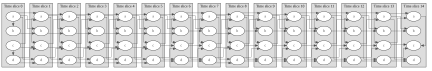

In [78]:
T = 15

dbn = gdyn.unroll2TBN(twodbn, T)
gdyn.showTimeSlices(dbn)

In [79]:
##### new P(ct|c0)
pot = gum.Tensor().add(twodbn["ct"]).add(twodbn["c0"])
pot.fillWith([1, 0, 0, 0.1] * 9).normalizeAsCPT()  # 36 valeurs normalized as CPT

(pyagrum.Tensor@0000019759B9BD30) 
      ||  ct                                                       |
c0    ||0        |1        |2        |3        |4        |5        |
------||---------|---------|---------|---------|---------|---------|
0     || 0.4762  | 0.0000  | 0.0000  | 0.0476  | 0.4762  | 0.0000  |
1     || 0.0000  | 0.0833  | 0.8333  | 0.0000  | 0.0000  | 0.0833  |
2     || 0.4762  | 0.0000  | 0.0000  | 0.0476  | 0.4762  | 0.0000  |
3     || 0.0000  | 0.0833  | 0.8333  | 0.0000  | 0.0000  | 0.0833  |
4     || 0.4762  | 0.0000  | 0.0000  | 0.0476  | 0.4762  | 0.0000  |
5     || 0.0000  | 0.0833  | 0.8333  | 0.0000  | 0.0000  | 0.0833  |

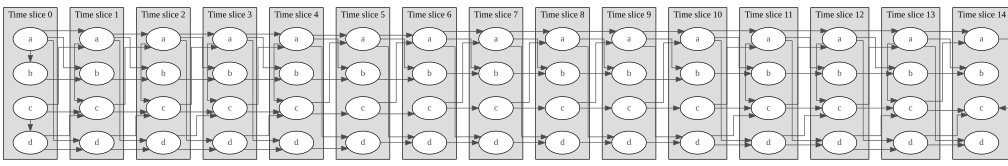

In [80]:
## from steps 5 to 10, $C_t$ only depends on $C_{t-1}$ and follows this new CPT
for i in range(5, 11):
  dbn.eraseArc(f"d{i - 1}", f"c{i}")
  dbn.eraseArc(f"a{i}", f"c{i}")
  dbn.cpt(f"c{i}").fillWith(pot, ["ct", "c0"])  # ct in pot <- first var of cpt, c0 in pot<-second var in cpt

gdyn.showTimeSlices(dbn, size="14")

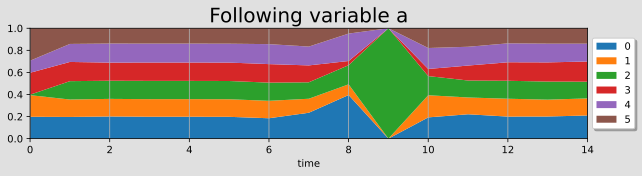

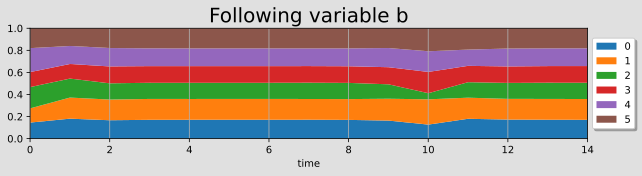

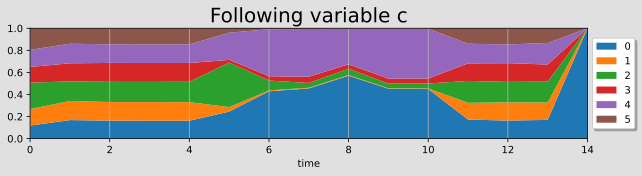

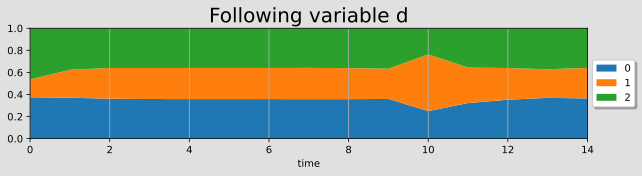

In [81]:
plt.rcParams["figure.figsize"] = (10, 2)
gdyn.plotFollowUnrolled(["a", "b", "c", "d"], dbn, T=15, evs={"a9": 2, "c14": 0})

### minimal example

In [82]:
bn = gum.BayesNet("Flooded_Critical_Infrastructure")


In [83]:
Flood = bn.add(gum.LabelizedVariable(
    "Flood", "Flood severity", ["low", "high"]
))

Power = bn.add(gum.LabelizedVariable(
    "Power", "Power system state", ["up", "down"]
))

Comm = bn.add(gum.LabelizedVariable(
    "Comm", "Communication system state", ["up", "down"]
))

Hospital = bn.add(gum.LabelizedVariable(
    "Hospital", "Hospital functionality", ["operational", "failed"]
))


In [ ]:
bn.addArc(Flood, Power)
bn.addArc(Power, Comm)
bn.addArc(Flood, Hospital)
bn.addArc(Comm, Hospital)

In [85]:
# 30% chance of severe flood
bn.cpt(Flood).fillWith([0.7, 0.3])

# power given flood
bn.cpt(Power)[{"Flood": "low"}]  = [0.95, 0.05]
bn.cpt(Power)[{"Flood": "high"}] = [0.40, 0.60]

# communication given power
bn.cpt(Comm)[{"Power": "up"}]   = [0.98, 0.02]
bn.cpt(Comm)[{"Power": "down"}] = [0.30, 0.70]

# hospital given flood and comm
bn.cpt(Hospital)[{"Flood": "low",  "Comm": "up"}]   = [0.99, 0.01]
bn.cpt(Hospital)[{"Flood": "low",  "Comm": "down"}] = [0.80, 0.20]
bn.cpt(Hospital)[{"Flood": "high", "Comm": "up"}]   = [0.70, 0.30]
bn.cpt(Hospital)[{"Flood": "high", "Comm": "down"}] = [0.20, 0.80]

In [86]:
ie = gum.LazyPropagation(bn)

ie.setEvidence({"Flood": "high"})
ie.makeInference()

posterior = ie.posterior("Hospital")
print(posterior)



  Hospital         |
operation|failed   |
---------|---------|
 0.4860  | 0.5140  |



### cascading example

In [88]:
bn = gum.BayesNet("Flood_Cascade_DBN")


In [89]:
# Flood intensity
Flood0 = gum.LabelizedVariable("Flood_0", "Flood at t0", 2)
Flood0.changeLabel(0, "low")
Flood0.changeLabel(1, "high")

Flood1 = Flood0.clone()
Flood1.setName("Flood_1")

# Power system
Power0 = gum.LabelizedVariable("Power_0", "Power at t0", 2)
Power0.changeLabel(0, "up")
Power0.changeLabel(1, "down")

Power1 = Power0.clone()
Power1.setName("Power_1")

# Hospital functionality
Hosp0 = gum.LabelizedVariable("Hosp_0", "Hospital at t0", 2)
Hosp0.changeLabel(0, "functional")
Hosp0.changeLabel(1, "failed")

Hosp1 = Hosp0.clone()
Hosp1.setName("Hosp_1")


In [90]:
for v in [Flood0, Flood1, Power0, Power1, Hosp0, Hosp1]:
    bn.add(v)


In [91]:
# Time 0
bn.addArc("Flood_0", "Power_0")
bn.addArc("Power_0", "Hosp_0")

# Time evolution
bn.addArc("Flood_1", "Power_1")
bn.addArc("Power_0", "Power_1")
bn.addArc("Power_1", "Hosp_1")
bn.addArc("Hosp_0", "Hosp_1")


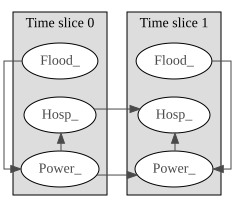

In [93]:
gdyn.showTimeSlices(bn)

In [92]:
power0_cpd = gum.Potential().add(Power0).add(Flood0)

power0_cpd.fillWith([
    0.95,  # Power up | Flood low
    0.30,  # Power up | Flood high
    0.05,  # Power down | Flood low
    0.70   # Power down | Flood high
])

bn.cpt("Power_0").fillWith(power0_cpd)


C:\Users\hai\AppData\Local\Temp\ipykernel_45328\757989307.py:1: DeprecationWarning: ** pyAgrum : The class pyagrum.Potential is deprecated since `pyAgrum>=2.0.0`. A pyagrum.Tensor will be returned instead.
  power0_cpd = gum.Potential().add(Power0).add(Flood0)


(pyagrum.Tensor@0000019759670630) 
      ||  Power_0          |
Flood_||up       |down     |
------||---------|---------|
low   || 0.9500  | 0.3000  |
high  || 0.0500  | 0.7000  |

In [96]:
power1_cpd = gum.Potential().add(Power1).add(Power0).add(Flood1)

# Order: Power1 | Power0, Flood1
power1_cpd.fillWith([
    # Flood low
    0.95, 0.80,   # Power up | (up, low), (down, low)
    0.05, 0.20,   # Power down | (up, low), (down, low)

    # Flood high
    0.30, 0.10,   # Power up | (up, high), (down, high)
    0.70, 0.90    # Power down | (up, high), (down, high)
])

bn.cpt("Power_1").fillWith(power1_cpd)


C:\Users\hai\AppData\Local\Temp\ipykernel_45328\1978418040.py:1: DeprecationWarning: ** pyAgrum : The class pyagrum.Potential is deprecated since `pyAgrum>=2.0.0`. A pyagrum.Tensor will be returned instead.
  power1_cpd = gum.Potential().add(Power1).add(Power0).add(Flood1)


(pyagrum.Tensor@00000197596701F0) 
             ||  Power_1          |
Flood_|Power_||up       |down     |
------|------||---------|---------|
low   |up    || 0.9500  | 0.8000  |
high  |up    || 0.3000  | 0.1000  |
low   |down  || 0.0500  | 0.2000  |
high  |down  || 0.7000  | 0.9000  |

In [99]:
bn.cpt("Hosp_0").fillWith([
    0.99, 0.20,   # functional | Power up/down
    0.01, 0.80    # failed | Power up/down
])

bn.cpt("Hosp_1").fillWith([
    # Hosp_1 = functional
    0.98,  # Power up,   Hosp0 functional
    0.30,  # Power down, Hosp0 functional
    0.60,  # Power up,   Hosp0 failed
    0.10,  # Power down, Hosp0 failed

    # Hosp_1 = failed
    0.02,  # Power up,   Hosp0 functional
    0.70,  # Power down, Hosp0 functional
    0.40,  # Power up,   Hosp0 failed
    0.90   # Power down, Hosp0 failed
])


(pyagrum.Tensor@0000019759670390) 
             ||  Hosp_1           |
Power_|Hosp_0||functiona|failed   |
------|------||---------|---------|
up    |functi|| 0.9800  | 0.3000  |
down  |functi|| 0.6000  | 0.1000  |
up    |failed|| 0.0200  | 0.7000  |
down  |failed|| 0.4000  | 0.9000  |

In [100]:
bn.cpt("Flood_0").fillWith([0.7, 0.3])   # mostly low
bn.cpt("Flood_1").fillWith([0.4, 0.6])   # worsening flood


(pyagrum.Tensor@0000019759670530) 
  Flood_1          |
low      |high     |
---------|---------|
 0.4000  | 0.6000  |

In [101]:
ie = gum.LazyPropagation(bn)
ie.makeInference()

print("P(Hospital failed at t1):")
print(ie.posterior("Hosp_1"))


P(Hospital failed at t1):

  Hosp_1           |
functiona|failed   |
---------|---------|
 0.5448  | 0.4552  |



# Custom Monte Carlo + Bayesian Network (BN)

1. Sample hazard (continuous) using Monte Carlo
2. Convert hazard → component damage probabilities (fragility curves)
3. Sample component states (functional / failed)
4. Inject states into BN as evidence
5. Run BN inference
6. Store outcomes
7. Repeat N times

In [102]:
import numpy as np

N = 10000  # Monte Carlo samples

# Example flood depth distribution (meters)
flood_depth = np.random.lognormal(mean=0.2, sigma=0.6, size=N)


In [103]:
def fragility(depth, a=3.0, b=1.5):
    return 1 / (1 + np.exp(-(a * depth - b)))


In [104]:
p_fail_power = fragility(flood_depth)
p_fail_comm  = fragility(flood_depth, a=2.5, b=1.2)
p_fail_hosp  = fragility(flood_depth, a=4.0, b=2.0)

In [105]:
power_state = np.random.binomial(1, p_fail_power)
comm_state  = np.random.binomial(1, p_fail_comm)
hosp_state  = np.random.binomial(1, p_fail_hosp)


In [106]:
import pyagrum as gum

bn = gum.BayesNet("InfraBN")

bn.add(gum.LabelizedVariable("Power", "Power", 2))
bn.add(gum.LabelizedVariable("Comm", "Comm", 2))
bn.add(gum.LabelizedVariable("Hosp", "Hosp", 2))

bn.addArc("Power", "Hosp")
bn.addArc("Comm", "Hosp")


In [107]:
bn.cpt("Power").fillWith([0.9, 0.1])
bn.cpt("Comm").fillWith([0.95, 0.05])

# Hosp depends on Power + Comm
bn.cpt("Hosp")[{'Power':0,'Comm':0}] = [0.99, 0.01]
bn.cpt("Hosp")[{'Power':1,'Comm':0}] = [0.60, 0.40]
bn.cpt("Hosp")[{'Power':0,'Comm':1}] = [0.70, 0.30]
bn.cpt("Hosp")[{'Power':1,'Comm':1}] = [0.20, 0.80]


In [108]:
ie = gum.LazyPropagation(bn)

results = []

for i in range(N):
    ie.eraseAllEvidence()
    
    ie.addEvidence("Power", int(power_state[i]))
    ie.addEvidence("Comm", int(comm_state[i]))

    ie.makeInference()
    
    p_hosp_fail = ie.posterior("Hosp")[1]
    results.append(p_hosp_fail)


In [109]:
import numpy as np

print("Expected hospital failure probability:",
      np.mean(results))

print("95% CI:",
      np.percentile(results, [2.5, 97.5]))


Expected hospital failure probability: 0.649129
95% CI: [0.01 0.8 ]


In [110]:
flood_t = np.maximum(0, flood_depth[:, None] - np.arange(5)*0.2)


In [112]:
import numpy as np
import pandas as pd

def simulate_cascade(timesteps=5, flood_depth=1.5):
    # Initial States: 1.0 = Functional, 0.0 = Failed
    nodes = ['plant', 'substation', 'comm', 'hospital']
    states = {node: np.ones(timesteps) for node in nodes}
    
    # Probabilistic Thresholds (Fragility)
    # Failure probability increases with flood depth
    p_flood_fail = 1 - np.exp(-0.5 * flood_depth) 

    for t in range(1, timesteps):
        # 1. Power Plant (External Hazard + Temporal Persistence)
        # If it failed at t-1, it stays failed. If functional, check flood impact.
        if states['plant'][t-1] == 0 or np.random.rand() < p_flood_fail:
            states['plant'][t] = 0
        
        # 2. Substation (Depends on Plant)
        if states['substation'][t-1] == 0 or states['plant'][t] == 0:
            states['substation'][t] = 0
            
        # 3. Communication (Depends on Substation)
        # We add a 10% chance of random failure even if power is on
        if states['comm'][t-1] == 0 or states['substation'][t] == 0 or np.random.rand() < 0.1:
            states['comm'][t] = 0
            
        # 4. Hospital (Depends on Substation AND Communication)
        # A hospital might have a backup generator (lowers failure probability)
        if states['hospital'][t-1] == 0:
            states['hospital'][t] = 0
        elif states['substation'][t] == 0 and states['comm'][t] == 0:
            states['hospital'][t] = 0 if np.random.rand() > 0.8 else 1 # 80% failure if both fail
        elif states['substation'][t] == 0 or states['comm'][t] == 0:
            states['hospital'][t] = 0 if np.random.rand() > 0.4 else 1 # 40% failure if one fails

    return pd.DataFrame(states)

# --- Monte Carlo Wrapper ---
iterations = 1000
results = []

for i in range(iterations):
    # Sample flood depth from a normal distribution (MC Step)
    sampled_flood = np.random.normal(loc=1.2, scale=0.5)
    df = simulate_cascade(timesteps=10, flood_depth=max(0, sampled_flood))
    results.append(df.iloc[-1]) # Store final state

# Analyze results
final_stats = pd.DataFrame(results).mean()
print("Probability of Functionality after Cascade:")
print(final_stats)

Probability of Functionality after Cascade:
plant         0.034
substation    0.034
comm          0.013
hospital      0.180
dtype: float64


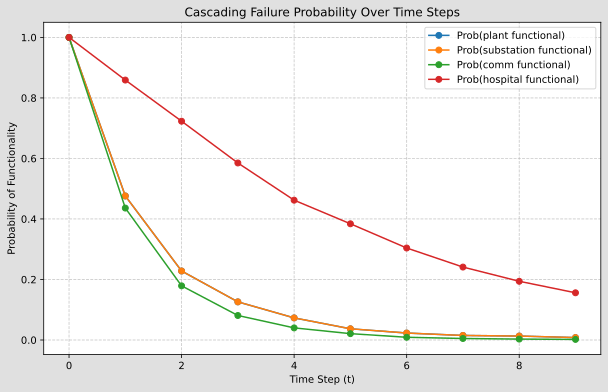

   plant  substation   comm  hospital
0  1.000       1.000  1.000     1.000
1  0.476       0.476  0.436     0.859
2  0.228       0.228  0.179     0.723
5  0.037       0.037  0.021     0.384
9  0.008       0.008  0.002     0.156


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_mc_simulation(iterations=1000, timesteps=10):
    # Dictionary to store the sum of states for averaging
    # Initialized with zeros
    total_states = {node: np.zeros(timesteps) for node in ['plant', 'substation', 'comm', 'hospital']}
    
    for i in range(iterations):
        # Sample flood depth (Monte Carlo)
        flood_depth = max(0, np.random.normal(loc=1.5, scale=0.4))
        
        # Current iteration states
        df_iter = simulate_cascade(timesteps=timesteps, flood_depth=flood_depth)
        
        # Accumulate results
        for node in total_states:
            total_states[node] += df_iter[node].values

    # Calculate probabilities (Mean)
    prob_df = pd.DataFrame(total_states) / iterations
    return prob_df

# Run and Plot
probabilities = run_mc_simulation()

plt.figure(figsize=(10, 6))
for column in probabilities.columns:
    plt.plot(probabilities[column], marker='o', label=f'Prob({column} functional)')

plt.title("Cascading Failure Probability Over Time Steps")
plt.xlabel("Time Step (t)")
plt.ylabel("Probability of Functionality")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Displaying the raw probability table for key steps
print(probabilities.iloc[[0, 1, 2, 5, 9]])